# Hybrid Quantum Machine Learning Platform for Early Disease Detection
## Stage 04-D: Dedicated 8-Feature Selection & 8-Qubit Noiseless Variational Quantum Classifier (VQC)
**Target Application:** Lung Cancer Classification  
**Target Variable:** `LUNG_CANCER` (0 = NO, 1 = YES)  
**Quantum Framework:** PennyLane (Analytic Statevector Simulation on `default.qubit`)  
**Hilbert Space Capacity:** $2^8 = 256$ Complex State Dimensions  

---

### End-to-End Module Objectives
1. **Dedicated 8-Feature Selection:** Execute training-derived relevance screening (Mutual Information, ANOVA F, Random Forest Gini) and Sequential Forward Selection (SFS) targeting **exactly 8 clinical predictors**.
2. **Strict Leakage Guardrail:** The holdout test set (`X_test`, `y_test`) remains 100% isolated until final holdout evaluation.
3. **8-Qubit 2-Layer VQC Architecture:**
   * **Qubit Register:** 8 Qubits ($q_0 \dots q_7$)
   * **Data Encoding:** $x_i \to RY(x_i \cdot \pi)$ for $i \in \{0 \dots 7\}$
   * **VQC Layer 1:** Rotations $RY(\theta_1 \dots \theta_8)$ + Linear nearest-neighbor CNOT ladder ($0\to 1\to 2\to 3\to 4\to 5\to 6\to 7$)
   * **VQC Layer 2:** Rotations $RY(\theta_9 \dots \theta_{16})$ + Linear nearest-neighbor CNOT ladder ($0\to 1\to 2\to 3\to 4\to 5\to 6\to 7$)
   * **Measurement:** Pauli-Z expectation across all 8 qubits $\langle Z_i \rangle$, pooled into $\langle Z \rangle = \frac{1}{8} \sum_{i=0}^7 \langle Z_i \rangle$.
   * **Total Parameters:** $8 \times 2 = 16$ quantum angles $\boldsymbol{\theta}$ + 1 classical bias $b$ = **17 parameters**.
4. **Benchmarking & Quantum Scaling:** Compare test set performance against the 4-Qubit baseline ($2^4 = 16$ dimensions) and 6-Qubit baseline ($2^6 = 64$ dimensions) to evaluate quantum state space scaling and expressibility.


In [1]:
# ==============================================================================
# 0. SETUP, IMPORTS & PATH CONFIGURATION
# ==============================================================================

import os
os.environ["MPLCONFIGDIR"] = "/tmp"

import json
import time
from pathlib import Path

import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Robust Base Directory Finder
current_notebook_dir = Path.cwd().resolve()
base_dir = current_notebook_dir
while not (base_dir / "artifacts").exists() and base_dir.parent != base_dir:
    base_dir = base_dir.parent

PREP_ARTIFACTS_DIR = base_dir / "artifacts" / "preprocessing"
VQC_4_DIR = base_dir / "Train_models" / "Hybrid_Quantum_ML" / "4-feature_Vqc"
VQC_6_DIR = base_dir / "Train_models" / "Hybrid_Quantum_ML" / "6-feature_Vqc"
OUTPUT_MODEL_DIR = base_dir / "Train_models" / "Hybrid_Quantum_ML" / "8-feature_VQC"
FIGURES_DIR = OUTPUT_MODEL_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pnp.random.seed(RANDOM_STATE)

print("Environment Configuration:")
print(f"  PennyLane Version: {qml.__version__}")
print(f"  Base Directory:    {base_dir}")
print(f"  Output Directory:  {OUTPUT_MODEL_DIR}")
print(f"  Figures Directory: {FIGURES_DIR}")


Environment Configuration:
  PennyLane Version: 0.45.1
  Base Directory:    /home/logith-p/Desktop/hybrid-qml-disease-detection
  Output Directory:  /home/logith-p/Desktop/hybrid-qml-disease-detection/Train_models/Hybrid_Quantum_ML/8-feature_VQC
  Figures Directory: /home/logith-p/Desktop/hybrid-qml-disease-detection/Train_models/Hybrid_Quantum_ML/8-feature_VQC/figures


---
## 1. Load Preprocessed 15-Feature Datasets

We ingest the clean, leakage-free 15-feature datasets generated by `02_preprocessing_and_split.ipynb`:
* `X_train.csv` & `y_train.csv` (70% partition, 2,098 samples)
* `X_validation.csv` & `y_validation.csv` (15% partition, 450 samples)
* `X_test.csv` & `y_test.csv` (15% holdout partition, 450 samples)


In [2]:
# ==============================================================================
# 1. INGEST PREPROCESSED DATASETS
# ==============================================================================

X_train_full = pd.read_csv(PREP_ARTIFACTS_DIR / "X_train.csv")
y_train_full = pd.read_csv(PREP_ARTIFACTS_DIR / "y_train.csv").squeeze().values
X_val_full = pd.read_csv(PREP_ARTIFACTS_DIR / "X_validation.csv")
y_val_full = pd.read_csv(PREP_ARTIFACTS_DIR / "y_validation.csv").squeeze().values
X_test_full = pd.read_csv(PREP_ARTIFACTS_DIR / "X_test.csv")
y_test_full = pd.read_csv(PREP_ARTIFACTS_DIR / "y_test.csv").squeeze().values

candidate_features = list(X_train_full.columns)

print("================================================================================")
print(" PREPROCESSED DATASET INGESTION SUMMARY")
print("================================================================================")
print(f"Total Candidate Features (15): {candidate_features}")
print(f"Training Observations:        {len(X_train_full):,} samples")
print(f"Validation Observations:      {len(X_val_full):,} samples")
print(f"Holdout Test Observations:    {len(X_test_full):,} samples")
print("================================================================================\n")

display(X_train_full.head(3))


 PREPROCESSED DATASET INGESTION SUMMARY
Total Candidate Features (15): ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH', 'SWALLOWING_DIFFICULTY', 'CHEST_PAIN']
Training Observations:        2,098 samples
Validation Observations:      450 samples
Holdout Test Observations:    450 samples



,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN
0,0.0,0.48,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
1,0.0,0.00,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,0.0,0.82,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0


---
## 2. Dedicated 8-Feature Selection Protocol

To construct an optimal 8-qubit quantum classifier without arbitrary feature guessing, we execute a rigorous two-stage feature selection protocol:

1. **Relevance Screening (Training Partition Only):**
   * **Mutual Information (`mutual_info_classif`)**: Non-linear shared entropy.
   * **ANOVA F-statistic (`f_classif`)**: Linear class separability.
   * **Random Forest Gini Utility (`RandomForestClassifier`)**: Tree ensemble split importance.
   * Composite rank averaging identifies the top candidate pool.

2. **Sequential Forward Selection (SFS) for Exactly 8 Features:**
   * Starts with an empty set $S_0 = \emptyset$.
   * Iteratively selects the unselected candidate that maximizes **Balanced Accuracy** on the validation partition:
     $$\text{Balanced Accuracy} = \frac{\text{Sensitivity} + \text{Specificity}}{2}$$
   * Stops when exactly 8 features are isolated.
   * **Zero Leakage:** The holdout test set (`X_test_full`, `y_test_full`) is never queried during selection.


In [3]:
# ==============================================================================
# 2. EXECUTE 8-FEATURE SELECTION (SFS LOOP)
# ==============================================================================

# 1. Relevance Screening on X_train only
mi_scores = mutual_info_classif(X_train_full, y_train_full, random_state=42)
f_scores, _ = f_classif(X_train_full, y_train_full)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_full, y_train_full)
rf_scores = rf.feature_importances_

relevance_df = pd.DataFrame({
    "Feature": candidate_features,
    "Mutual_Information": mi_scores,
    "ANOVA_F_Statistic": f_scores,
    "Random_Forest_Gini": rf_scores
})
relevance_df["MI_Rank"] = relevance_df["Mutual_Information"].rank(ascending=False)
relevance_df["F_Rank"] = relevance_df["ANOVA_F_Statistic"].rank(ascending=False)
relevance_df["RF_Rank"] = relevance_df["Random_Forest_Gini"].rank(ascending=False)
relevance_df["Composite_Score"] = (relevance_df["MI_Rank"] + relevance_df["F_Rank"] + relevance_df["RF_Rank"]) / 3.0
relevance_df = relevance_df.sort_values("Composite_Score").reset_index(drop=True)

relevance_df.to_csv(OUTPUT_MODEL_DIR / "feature_relevance_ranking_8.csv", index=False)

# Top 12 candidates shortlisted for sequential forward selection
shortlisted_candidates = list(relevance_df["Feature"].head(12))

# 2. Sequential Forward Selection (SFS) targeting exactly 8 features
def eval_subset(feats):
    clf = LogisticRegression(random_state=42, solver="lbfgs")
    clf.fit(X_train_full[feats], y_train_full)
    y_pred = clf.predict(X_val_full[feats])
    y_prob = clf.predict_proba(X_val_full[feats])[:, 1]
    return {
        "Accuracy": float(accuracy_score(y_val_full, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_val_full, y_pred)),
        "Sensitivity": float(recall_score(y_val_full, y_pred, pos_label=1, zero_division=0)),
        "Specificity": float(recall_score(y_val_full, y_pred, pos_label=0, zero_division=0)),
        "ROC_AUC": float(roc_auc_score(y_val_full, y_prob))
    }

selected_8 = []
remaining = list(shortlisted_candidates)
sfs_history = []

print("Executing Sequential Forward Selection for 8 Features...")
for step in range(1, 9):
    best_cand = None
    best_bacc = -1.0
    best_m = None
    for cand in remaining:
        trial = selected_8 + [cand]
        m = eval_subset(trial)
        if m["Balanced_Accuracy"] > best_bacc:
            best_bacc = m["Balanced_Accuracy"]
            best_cand = cand
            best_m = m
    selected_8.append(best_cand)
    remaining.remove(best_cand)
    sfs_history.append({
        "Step": step,
        "Selected_Feature": best_cand,
        "Cumulative_Feature_Set": list(selected_8),
        **best_m
    })
    print(f"  Step {step}: Selected '{best_cand}' -> Val Balanced Acc: {best_bacc:.4f} | ROC-AUC: {best_m['ROC_AUC']:.4f}")

sfs_df = pd.DataFrame(sfs_history)
sfs_df.to_csv(OUTPUT_MODEL_DIR / "feature_selection_summary_8.csv", index=False)

with open(OUTPUT_MODEL_DIR / "selected_features_8.json", "w") as f:
    json.dump(selected_8, f, indent=4)

# Subsetting dataset matrices
X_train_8 = X_train_full[selected_8].values.astype(float)
X_val_8 = X_val_full[selected_8].values.astype(float)
X_test_8 = X_test_full[selected_8].values.astype(float)

# Also save standalone CSV files for 8 features
pd.DataFrame(X_train_8, columns=selected_8).to_csv(OUTPUT_MODEL_DIR / "X_train_8.csv", index=False)
pd.DataFrame(X_val_8, columns=selected_8).to_csv(OUTPUT_MODEL_DIR / "X_validation_8.csv", index=False)
pd.DataFrame(X_test_8, columns=selected_8).to_csv(OUTPUT_MODEL_DIR / "X_test_8.csv", index=False)

y_train = y_train_full.astype(float)
y_val = y_val_full.astype(float)
y_test = y_test_full.astype(float)

print(f"\nFinal 8 Selected Features: {selected_8}")


Executing Sequential Forward Selection for 8 Features...


  Step 1: Selected 'COUGHING' -> Val Balanced Acc: 0.5202 | ROC-AUC: 0.5202


  Step 2: Selected 'PEER_PRESSURE' -> Val Balanced Acc: 0.5303 | ROC-AUC: 0.5414


  Step 3: Selected 'AGE' -> Val Balanced Acc: 0.5331 | ROC-AUC: 0.5438
  Step 4: Selected 'ANXIETY' -> Val Balanced Acc: 0.5426 | ROC-AUC: 0.5417


  Step 5: Selected 'ALLERGY' -> Val Balanced Acc: 0.5426 | ROC-AUC: 0.5410
  Step 6: Selected 'SHORTNESS_OF_BREATH' -> Val Balanced Acc: 0.5359 | ROC-AUC: 0.5402


  Step 7: Selected 'CHEST_PAIN' -> Val Balanced Acc: 0.5268 | ROC-AUC: 0.5405
  Step 8: Selected 'CHRONIC_DISEASE' -> Val Balanced Acc: 0.5207 | ROC-AUC: 0.5171

Final 8 Selected Features: ['COUGHING', 'PEER_PRESSURE', 'AGE', 'ANXIETY', 'ALLERGY', 'SHORTNESS_OF_BREATH', 'CHEST_PAIN', 'CHRONIC_DISEASE']


---
## 3. Quantum Device & 8-Qubit 2-Layer VQC Architecture

### Quantum Architectural Specification:
1. **Device**: `default.qubit` (8 wires, noiseless analytic statevector simulator).
2. **Hilbert Space**: $2^8 = 256$ complex basis states ($|00000000\rangle \dots |11111111\rangle$).
3. **Data Encoding (Angle Embedding)**:
   Each classical feature $x_j \in [0, 1]$ is embedded via single-qubit Pauli rotation $R_y(x_j \cdot \pi)$ on wire $j$:
   $$|\psi_0(\mathbf{x})\rangle = \bigotimes_{j=0}^7 R_y(x_j \cdot \pi) |0\rangle$$
4. **VQC Layer 1 (Trainable Parameters $\theta_1 \dots \theta_8$)**:
   * Single-qubit rotations: $RY(\theta_1) \dots RY(\theta_8)$ on wires $0 \dots 7$.
   * Linear nearest-neighbor CNOT ladder: $\text{CNOT}(0, 1) \to \text{CNOT}(1, 2) \to \text{CNOT}(2, 3) \to \dots \to \text{CNOT}(6, 7)$ (7 entangling gates).
5. **VQC Layer 2 (Trainable Parameters $\theta_9 \dots \theta_{16}$)**:
   * Single-qubit rotations: $RY(\theta_9) \dots RY(\theta_{16})$ on wires $0 \dots 7$.
   * Linear nearest-neighbor CNOT ladder: $\text{CNOT}(0, 1) \to \text{CNOT}(1, 2) \to \text{CNOT}(2, 3) \to \dots \to \text{CNOT}(6, 7)$ (7 entangling gates).
6. **Observable & Measurement**:
   * Pauli-Z expectation value on each of the 8 qubits: $\langle Z_i \rangle$.
   * Pooled scalar: $\langle Z \rangle = \frac{1}{8} \sum_{i=0}^7 \langle Z_i \rangle$.
7. **Classical Classification Head**:
   * $\hat{p} = \sigma(\langle Z \rangle + b) = \frac{1}{1 + e^{-(\langle Z \rangle + b)}}$.
   * Total trainable parameters: $8 \times 2 = 16$ quantum angles + 1 classical bias = **17 total parameters**.


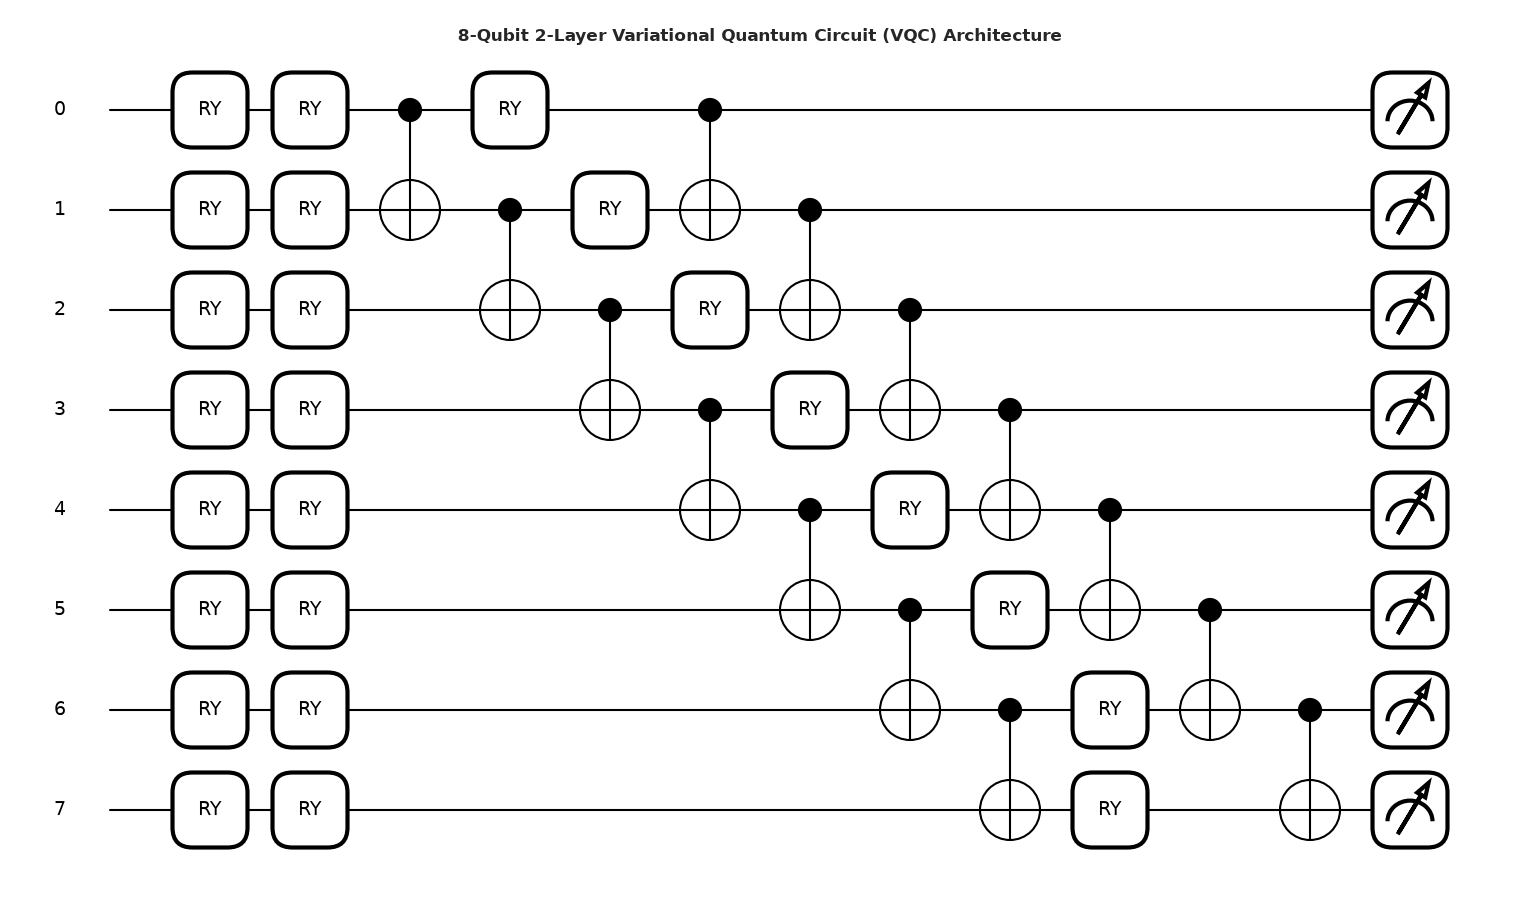

Quantum Circuit Architecture (ASCII):
0: ──RY(3.14)──RY(0.00)─╭●──RY(0.00)───────────╭●─────────────────────────────────────────────── ···
1: ──RY(0.00)──RY(0.00)─╰X─╭●─────────RY(0.00)─╰X────────╭●───────────────────────────────────── ···
2: ──RY(1.51)──RY(0.00)────╰X────────╭●─────────RY(0.00)─╰X────────╭●─────────────────────────── ···
3: ──RY(3.14)──RY(0.00)──────────────╰X────────╭●─────────RY(0.00)─╰X────────╭●───────────────── ···
4: ──RY(3.14)──RY(0.00)────────────────────────╰X────────╭●─────────RY(0.00)─╰X────────╭●─────── ···
5: ──RY(0.00)──RY(0.00)──────────────────────────────────╰X────────╭●─────────RY(0.00)─╰X─────── ···
6: ──RY(3.14)──RY(0.00)────────────────────────────────────────────╰X────────╭●─────────RY(0.00) ···
7: ──RY(0.00)──RY(0.00)──────────────────────────────────────────────────────╰X─────────RY(0.00) ···

0: ··· ───────┤  <Z>
1: ··· ───────┤  <Z>
2: ··· ───────┤  <Z>
3: ··· ───────┤  <Z>
4: ··· ───────┤  <Z>
5: ··· ─╭●────┤  <Z>
6: ··· ─╰X─╭●─┤  <Z>
7: ···

In [4]:
# ==============================================================================
# 3. PENNYLANE 8-QUBIT 2-LAYER VQC QUANTUM NODE
# ==============================================================================

n_qubits = 8
n_layers = 2

# Instantiate noiseless statevector simulator for 8 qubits
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def vqc_8_circuit(x, weights):
    # 1. Feature Map: Angle Embedding RY(x_i * pi)
    for i in range(n_qubits):
        qml.RY(x[..., i] * pnp.pi, wires=i)
        
    # 2. VQC Layer 1: RY(theta_1..theta_8) + Linear CNOT Entanglement
    for i in range(n_qubits):
        qml.RY(weights[0, i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
        
    # 3. VQC Layer 2: RY(theta_9..theta_16) + Linear CNOT Entanglement
    for i in range(n_qubits):
        qml.RY(weights[1, i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
        
    # 4. Measurement: Pauli-Z expectation across all 8 qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

def forward_probabilities(x, weights, bias):
    """
    Computes binary classification probability p(y=1|x):
    sigma(<Z> + bias) where <Z> is the mean Pauli-Z expectation across all 8 qubits.
    """
    res = vqc_8_circuit(x, weights)
    stacked = pnp.stack(res, axis=-1)
    z_mean = pnp.mean(stacked, axis=-1)
    logits = z_mean + bias
    return 1.0 / (1.0 + pnp.exp(-logits))

def loss_fn(weights, bias, x, y):
    probs = forward_probabilities(x, weights, bias)
    probs_clipped = pnp.clip(probs, 1e-7, 1.0 - 1e-7)
    return -pnp.mean(y * pnp.log(probs_clipped) + (1.0 - y) * pnp.log(1.0 - probs_clipped))

# Draw and display quantum circuit schematic
sample_x = pnp.array(X_train_8[0], requires_grad=False)
sample_w = pnp.zeros((n_layers, n_qubits), requires_grad=False)

fig, ax = qml.draw_mpl(vqc_8_circuit)(sample_x, sample_w)
fig.suptitle("8-Qubit 2-Layer Variational Quantum Circuit (VQC) Architecture", fontsize=12, fontweight="bold")
plt.savefig(FIGURES_DIR / "vqc_8_circuit_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

print("Quantum Circuit Architecture (ASCII):")
print(qml.draw(vqc_8_circuit)(sample_x, sample_w))


---
## 4. Mini-Batch Training Loop with Validation Checkpointing

We optimize the 17 parameters using:
* **Optimizer**: PennyLane `AdamOptimizer(stepsize=0.03)`
* **Loss Function**: Binary Cross-Entropy (BCE) with $\epsilon$-clipping
* **Batch Size**: 64 samples per mini-batch
* **Epochs**: 20 epochs
* **Model Checkpointing**: The parameters $(\mathbf{W}^*, b^*)$ yielding the lowest validation loss are checkpointed.


In [5]:
# ==============================================================================
# 4. 8-QUBIT VQC TRAINING EXECUTION
# ==============================================================================

# Initialize trainable parameters: 16 quantum rotation angles + 1 classical bias
weights = pnp.random.uniform(0.0, 2.0 * pnp.pi, (n_layers, n_qubits), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)

total_params = weights.size + 1
print(f"Total Trainable Parameters: {total_params} ({weights.size} quantum rotation angles [theta_1..theta_16] + 1 classical bias)")

optimizer = qml.AdamOptimizer(stepsize=0.03)
batch_size = 64
n_epochs = 20

best_val_loss = float("inf")
best_weights = weights.copy()
best_bias = bias.copy()
best_epoch = 0

history = []
X_val_pnp = pnp.array(X_val_8, requires_grad=False)
y_val_pnp = pnp.array(y_val, requires_grad=False)

print("Starting 8-Qubit Noiseless VQC Training Protocol...")
print("--------------------------------------------------------------------------------")

start_time = time.time()

for epoch in range(1, n_epochs + 1):
    epoch_start = time.time()
    permutation = np.random.permutation(len(X_train_8))
    X_shuffled = X_train_8[permutation]
    y_shuffled = y_train[permutation]
    
    batch_losses = []
    for i in range(0, len(X_train_8), batch_size):
        xb = pnp.array(X_shuffled[i:i + batch_size], requires_grad=False)
        yb = pnp.array(y_shuffled[i:i + batch_size], requires_grad=False)
        (weights, bias), batch_l = optimizer.step_and_cost(
            lambda w, b: loss_fn(w, b, xb, yb),
            weights,
            bias
        )
        batch_losses.append(float(batch_l))
        
    train_loss = float(np.mean(batch_losses))
    val_loss = float(loss_fn(weights, bias, X_val_pnp, y_val_pnp))
    
    val_probs = np.array(forward_probabilities(X_val_pnp, weights, bias))
    val_preds = (val_probs >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_preds)
    val_bacc = balanced_accuracy_score(y_val, val_preds)
    val_auc = roc_auc_score(y_val, val_probs)
    
    is_best = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = weights.copy()
        best_bias = bias.copy()
        best_epoch = epoch
        is_best = " [*Best Model]"
        
    epoch_time = time.time() - epoch_start
    history.append({
        "Epoch": epoch,
        "Train Loss": round(train_loss, 4),
        "Val Loss": round(val_loss, 4),
        "Val Accuracy": round(val_acc, 4),
        "Val Balanced Acc": round(val_bacc, 4),
        "Val ROC-AUC": round(val_auc, 4),
        "Time (s)": round(epoch_time, 2)
    })
    
    print(f"Epoch {epoch:02d}/{n_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val Balanced Acc: {val_bacc:.4f} | Val AUC: {val_auc:.4f} ({epoch_time:.2f}s){is_best}")

total_time = time.time() - start_time
print("--------------------------------------------------------------------------------")
print(f"Training completed in {total_time:.2f}s. Best Checkpoint: Epoch {best_epoch:02d} (Val Loss: {best_val_loss:.4f})")

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_MODEL_DIR / "training_history_8.csv", index=False)
np.save(OUTPUT_MODEL_DIR / "vqc_8_weights.npy", np.array(best_weights))
np.save(OUTPUT_MODEL_DIR / "vqc_8_bias.npy", np.array(best_bias))


Total Trainable Parameters: 17 (16 quantum rotation angles [theta_1..theta_16] + 1 classical bias)
Starting 8-Qubit Noiseless VQC Training Protocol...
--------------------------------------------------------------------------------


Epoch 01/20 | Train Loss: 0.6935 | Val Loss: 0.6930 | Val Balanced Acc: 0.4969 | Val AUC: 0.5123 (2.13s) [*Best Model]


Epoch 02/20 | Train Loss: 0.6927 | Val Loss: 0.6926 | Val Balanced Acc: 0.5159 | Val AUC: 0.5205 (1.69s) [*Best Model]


Epoch 03/20 | Train Loss: 0.6915 | Val Loss: 0.6930 | Val Balanced Acc: 0.5180 | Val AUC: 0.5217 (1.71s)


Epoch 04/20 | Train Loss: 0.6910 | Val Loss: 0.6942 | Val Balanced Acc: 0.5120 | Val AUC: 0.5145 (1.78s)


...

Epoch 16/20 | Train Loss: 0.6884 | Val Loss: 0.6984 | Val Balanced Acc: 0.4864 | Val AUC: 0.4810 (1.73s)


Epoch 17/20 | Train Loss: 0.6882 | Val Loss: 0.6987 | Val Balanced Acc: 0.4630 | Val AUC: 0.4796 (1.84s)


Epoch 18/20 | Train Loss: 0.6887 | Val Loss: 0.6992 | Val Balanced Acc: 0.4865 | Val AUC: 0.4769 (1.73s)


Epoch 19/20 | Train Loss: 0.6886 | Val Loss: 0.6991 | Val Balanced Acc: 0.5023 | Val AUC: 0.4782 (1.85s)


Epoch 20/20 | Train Loss: 0.6885 | Val Loss: 0.6995 | Val Balanced Acc: 0.4769 | Val AUC: 0.4753 (1.73s)
--------------------------------------------------------------------------------
Training completed in 35.36s. Best Checkpoint: Epoch 02 (Val Loss: 0.6926)


---
## 5. Training Progression Visualizations

We plot the training loss curve and the validation balanced accuracy progression across the 20 epochs.


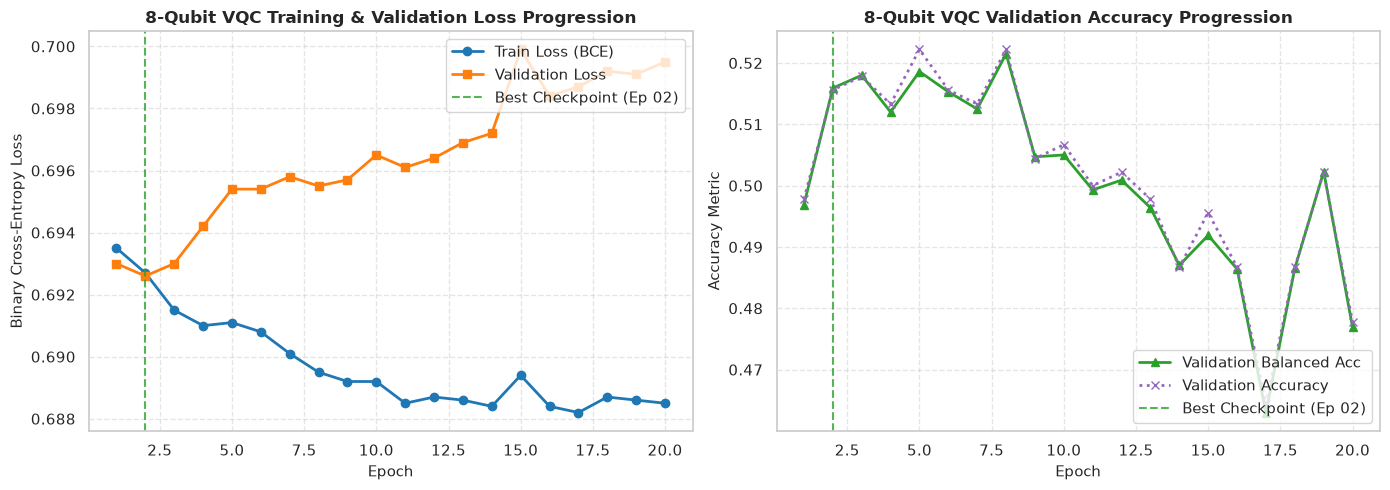

In [6]:
# ==============================================================================
# 5. PLOT 8-QUBIT VQC PROGRESSION
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
axes[0].plot(history_df["Epoch"], history_df["Train Loss"], marker="o", linewidth=2, label="Train Loss (BCE)", color="#1f77b4")
axes[0].plot(history_df["Epoch"], history_df["Val Loss"], marker="s", linewidth=2, label="Validation Loss", color="#ff7f0e")
axes[0].axvline(best_epoch, color="#2ca02c", linestyle="--", alpha=0.8, label=f"Best Checkpoint (Ep {best_epoch:02d})")
axes[0].set_title("8-Qubit VQC Training & Validation Loss Progression", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Binary Cross-Entropy Loss", fontsize=11)
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Balanced Accuracy Curves
axes[1].plot(history_df["Epoch"], history_df["Val Balanced Acc"], marker="^", linewidth=2, label="Validation Balanced Acc", color="#2ca02c")
axes[1].plot(history_df["Epoch"], history_df["Val Accuracy"], marker="x", linewidth=2, linestyle=":", label="Validation Accuracy", color="#9467bd")
axes[1].axvline(best_epoch, color="#2ca02c", linestyle="--", alpha=0.8, label=f"Best Checkpoint (Ep {best_epoch:02d})")
axes[1].set_title("8-Qubit VQC Validation Accuracy Progression", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy Metric", fontsize=11)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "vqc_8_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 6. Final Out-of-Sample Evaluation on Holdout Test Set

We evaluate the optimal checkpointed 8-Qubit VQC model on the 450 unseen holdout patient samples from `X_test_8.csv`.


 FINAL 8-QUBIT TEST SET EVALUATION REPORT (450 SAMPLES)
Accuracy:                 48.44%
Balanced Accuracy:        48.50%
Sensitivity (Recall):     42.73%
Specificity:              54.26%
Precision:                48.74%
F1-Score:                 45.54%
ROC-AUC:                  0.4990
--------------------------------------------------------------------------------
Confusion Matrix: TN=121, FP=102, FN=130, TP=97


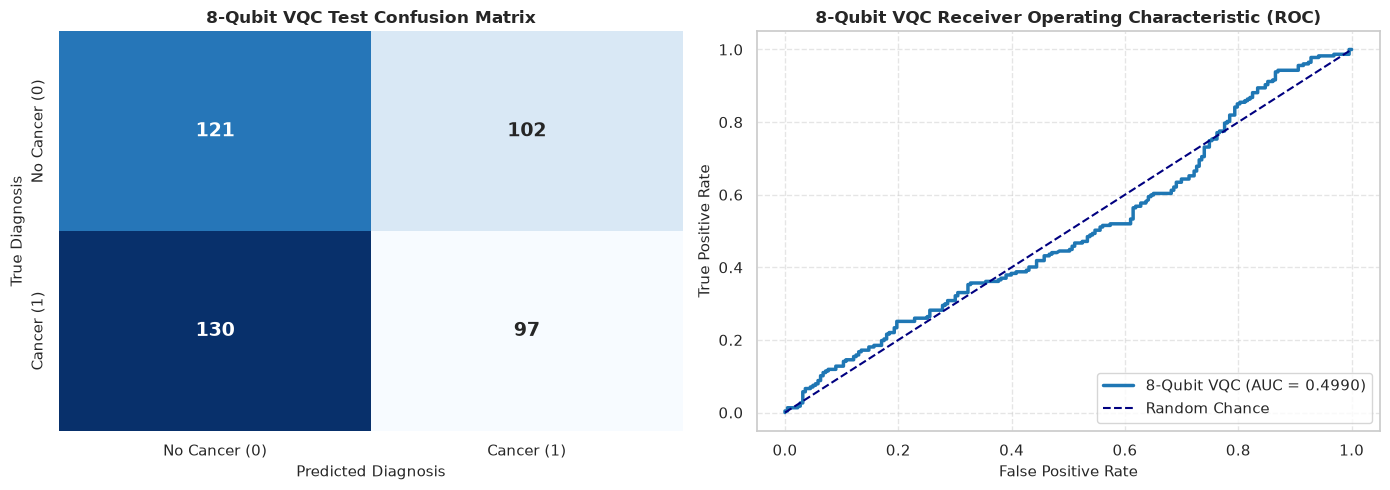

In [7]:
# ==============================================================================
# 6. HOLDOUT TEST SET EVALUATION (8-QUBIT VQC)
# ==============================================================================

X_test_pnp = pnp.array(X_test_8, requires_grad=False)
test_probs = np.array(forward_probabilities(X_test_pnp, best_weights, best_bias))
test_preds = (test_probs >= 0.5).astype(int)

test_acc = float(accuracy_score(y_test, test_preds))
test_bacc = float(balanced_accuracy_score(y_test, test_preds))
test_sens = float(recall_score(y_test, test_preds, pos_label=1))
test_spec = float(recall_score(y_test, test_preds, pos_label=0))
test_prec = float(precision_score(y_test, test_preds, pos_label=1, zero_division=0))
test_f1 = float(f1_score(y_test, test_preds, pos_label=1, zero_division=0))
test_auc = float(roc_auc_score(y_test, test_probs))
cm = confusion_matrix(y_test, test_preds)

print("================================================================================")
print(" FINAL 8-QUBIT TEST SET EVALUATION REPORT (450 SAMPLES)")
print("================================================================================")
print(f"Accuracy:                 {test_acc * 100:.2f}%")
print(f"Balanced Accuracy:        {test_bacc * 100:.2f}%")
print(f"Sensitivity (Recall):     {test_sens * 100:.2f}%")
print(f"Specificity:              {test_spec * 100:.2f}%")
print(f"Precision:                {test_prec * 100:.2f}%")
print(f"F1-Score:                 {test_f1 * 100:.2f}%")
print(f"ROC-AUC:                  {test_auc:.4f}")
print("--------------------------------------------------------------------------------")
print(f"Confusion Matrix: TN={cm[0, 0]}, FP={cm[0, 1]}, FN={cm[1, 0]}, TP={cm[1, 1]}")
print("================================================================================")

# Plot Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["No Cancer (0)", "Cancer (1)"],
            yticklabels=["No Cancer (0)", "Cancer (1)"],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("8-Qubit VQC Test Confusion Matrix", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Diagnosis", fontsize=11)
axes[0].set_ylabel("True Diagnosis", fontsize=11)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, color="#1f77b4", lw=2.5, label=f"8-Qubit VQC (AUC = {test_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Chance")
axes[1].set_title("8-Qubit VQC Receiver Operating Characteristic (ROC)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "vqc_8_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.savefig(FIGURES_DIR / "vqc_8_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 7. Quantum Scaling Benchmark: 4-Qubit vs. 6-Qubit vs. 8-Qubit VQC

We load the baseline metrics from:
* `Train_models/Hybrid_Quantum_ML/4-feature_Vqc/test_metrics.json` (16-D Hilbert Space)
* `Train_models/Hybrid_Quantum_ML/6-feature_Vqc/test_metrics_6.json` (64-D Hilbert Space)

and evaluate the scaling behavior up to 8 qubits (256-D Hilbert Space).


Saved: test_metrics_8.json
Saved: vqc_8_weights.npy & vqc_8_bias.npy
Saved: training_history_8.csv


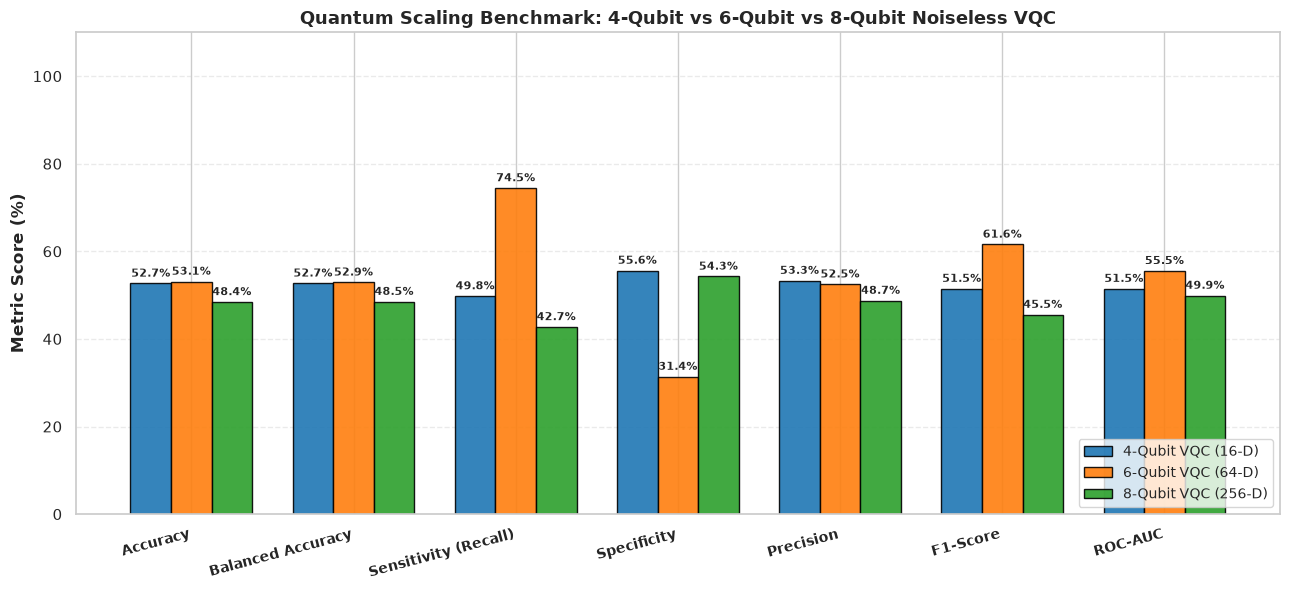

Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/Train_models/Hybrid_Quantum_ML/8-feature_VQC/figures/quantum_scaling_comparison_4_6_8.png

             8-QUBIT NOISELESS VQC TRAINING & EVALUATION COMPLETE


In [8]:
# ==============================================================================
# 7. QUANTUM SCALING BENCHMARK (4 vs 6 vs 8 QUBITS) & ARTIFACT EXPORT
# ==============================================================================

test_summary_8 = {
    "model": "8-Qubit Noiseless Variational Quantum Classifier (VQC)",
    "framework": f"PennyLane {qml.__version__}",
    "device": "default.qubit (statevector simulator)",
    "hilbert_space_dimension": 256,
    "features": selected_8,
    "n_qubits": n_qubits,
    "n_layers": n_layers,
    "test_samples": len(y_test),
    "best_training_epoch": best_epoch,
    "metrics": {
        "Accuracy": round(test_acc, 4),
        "Balanced Accuracy": round(test_bacc, 4),
        "Sensitivity (Recall)": round(test_sens, 4),
        "Specificity": round(test_spec, 4),
        "Precision": round(test_prec, 4),
        "F1-Score": round(test_f1, 4),
        "ROC-AUC": round(test_auc, 4)
    },
    "confusion_matrix": {
        "True Negative": int(cm[0, 0]),
        "False Positive": int(cm[0, 1]),
        "False Negative": int(cm[1, 0]),
        "True Positive": int(cm[1, 1])
    }
}

with open(OUTPUT_MODEL_DIR / "test_metrics_8.json", "w") as f:
    json.dump(test_summary_8, f, indent=4)

print("Saved: test_metrics_8.json")
print("Saved: vqc_8_weights.npy & vqc_8_bias.npy")
print("Saved: training_history_8.csv")

# 3-Way Scaling Comparison: 4 vs 6 vs 8 Qubits
vqc_4_metrics_path = VQC_4_DIR / "test_metrics.json"
vqc_6_metrics_path = VQC_6_DIR / "test_metrics_6.json"

models_data = {}
if vqc_4_metrics_path.exists():
    with open(vqc_4_metrics_path, "r") as f:
        models_data["4-Qubit VQC (16-D)"] = json.load(f)["metrics"]
if vqc_6_metrics_path.exists():
    with open(vqc_6_metrics_path, "r") as f:
        models_data["6-Qubit VQC (64-D)"] = json.load(f)["metrics"]
models_data["8-Qubit VQC (256-D)"] = test_summary_8["metrics"]

comp_keys = [
    ("Accuracy", "Accuracy"),
    ("Balanced Accuracy", "Balanced Accuracy"),
    ("Sensitivity (Recall)", "Sensitivity"),
    ("Specificity", "Specificity"),
    ("Precision", "Precision"),
    ("F1-Score", "F1-Score"),
    ("ROC-AUC", "ROC-AUC")
]

x = np.arange(len(comp_keys))
total_models = len(models_data)
bar_width = 0.25
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(13, 6))

for idx, (m_name, m_dict) in enumerate(models_data.items()):
    vals = []
    for k_primary, k_alt in comp_keys:
        v = m_dict.get(k_primary, m_dict.get(k_alt, 0.0))
        vals.append(v * 100.0)
    
    pos = x + (idx - (total_models - 1) / 2) * bar_width
    rects = ax.bar(pos, vals, bar_width, label=m_name, color=colors[idx % len(colors)], edgecolor="black", alpha=0.9)
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_ylabel("Metric Score (%)", fontsize=12, fontweight="bold")
ax.set_title("Quantum Scaling Benchmark: 4-Qubit vs 6-Qubit vs 8-Qubit Noiseless VQC", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([k[0] for k in comp_keys], rotation=15, ha="right", fontsize=10, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.set_ylim(0, 110)
ax.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
comp_fig_path = FIGURES_DIR / "quantum_scaling_comparison_4_6_8.png"
plt.savefig(comp_fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {comp_fig_path}")

print("\n================================================================================")
print("             8-QUBIT NOISELESS VQC TRAINING & EVALUATION COMPLETE")
print("================================================================================")
